# Projet P11 - Notebook 2 : ACP, clustering et recommandations commerciales

## Lexique des variables utilisées dans le notebook 2

Le notebook 2 recharge le dataset prépare dans le notebook 1. Les variables ci-dessous sont donc déjà construites en amont, puis mobilisées ici pour l'ACP, le clustering et le scoring final.

### Variables de marché actuel

- `volaille_kcal_hab_jour` : apport quotidien en calories provenant de la volaille par habitant.
- `volaille_kg_hab_an` : quantité annuelle de volaille disponible par habitant.
- `volaille_production_tonnes` : production nationale de viande de volaille.
- `volaille_import_tonnes` : volume importe de viande de volaille.
- `volaille_disponibilite_tonnes` : disponibilité intérieure totale de viande de volaille.
- `marche_volaille_tonnes` : estimation de la taille totale du marché de la volaille.
- `taux_dependance_import` : part de la disponibilité intérieure couverte par les importations.
- `part_volaille_dans_consommation_viande` : poids de la volaille dans la consommation totale de viande.
- `part_proteines_volaille_dans_viandes` : part des protéines de volaille dans les protéines issues de la viande.
- `prix_moyen_import_volaille_usd_tonne` : prix moyen à l'importation de la viande de volaille, calcule à partir des statistiques de commerce FAO.

### Variables économiques et démographiques

- `pib_hab_ppp` : PIB par habitant en parité de pouvoir d'achat.
- `croissance_pib_pct` : croissance annuelle du PIB.
- `pct_population_urbaine` : part de la population vivant en zone urbaine en 2017.
- `imports_alimentaires_pct` : poids des importations alimentaires dans les importations de marchandises.

### Variables de dynamique de demande

- `croissance_population_urbaine_pct` : croissance annuelle moyenne de la population urbaine entre 2013 et 2017.
- `variation_part_urbaine_points` : évolution de la part urbaine entre 2013 et 2017, en points.
- `croissance_conso_volaille_pct` : croissance annuelle moyenne de la consommation de volaille entre 2013 et 2017.
- `croissance_import_volaille_pct` : croissance annuelle moyenne des importations de volaille entre 2013 et 2017.

### Variables alimentaires et pouvoir d'achat

- `proteines_animales_g_hab_jour` : disponibilités moyennes de protéines d'origine animale sur la période 2015-2017.
- `sous_alimentation_pct` : prévalence moyenne de la sous-alimentation sur la période 2015-2017.
- `cout_alimentation_saine_ppp_jour` : cout d'une alimentation saine en 2017, en dollars internationaux PPA par personne et par jour.
- `prevalence_inabordabilite_alimentation_saine_pct` : part de la population ne pouvant pas s'offrir une alimentation saine en 2017.

### Variables de risque pays

- `score_stabilite_politique` : score WGI de stabilité politique et d'absence de violence, sur 100.
- `indice_gouvernance_moyen` : moyenne simple des scores WGI retenus dans le notebook 1.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').exists() and (ROOT.parent / 'src').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

MODELING_FEATURES = [
    'volaille_kcal_hab_jour',
    'volaille_kg_hab_an',
    'volaille_production_tonnes',
    'volaille_import_tonnes',
    'volaille_disponibilite_tonnes',
    'pib_hab_ppp',
    'croissance_pib_pct',
    'pct_population_urbaine',
    'imports_alimentaires_pct',
    'croissance_population_urbaine_pct',
    'variation_part_urbaine_points',
    'croissance_conso_volaille_pct',
    'croissance_import_volaille_pct',
    'prix_moyen_import_volaille_usd_tonne',
    'proteines_animales_g_hab_jour',
    'sous_alimentation_pct',
    'cout_alimentation_saine_ppp_jour',
    'prevalence_inabordabilite_alimentation_saine_pct',
    'score_stabilite_politique',
    'indice_gouvernance_moyen',
    'marche_volaille_tonnes',
    'taux_dependance_import',
    'part_volaille_dans_consommation_viande',
    'part_proteines_volaille_dans_viandes',
]


## 1. Chargement du dataset préparé


In [2]:
df = pd.read_csv(ROOT / "outputs" / "dataset_p11.csv")
df.head()


,pays,iso3,continent,landlocked,distance_france_km,population_totale,population_milliers,croissance_population_pct,croissance_population_urbaine_pct,variation_part_urbaine_points,croissance_conso_volaille_pct,croissance_import_volaille_pct,volaille_kcal_hab_jour,volaille_kg_hab_an,viande_totale_kg_hab_an,proteines_volaille_g_hab_jour,proteines_viande_totale_g_hab_jour,proteines_animales_g_hab_jour,volaille_production_tonnes,volaille_import_tonnes,volaille_disponibilite_tonnes,volaille_import_quantite_trade_tonnes,volaille_export_quantite_trade_tonnes,volaille_import_valeur_kusd,volaille_export_valeur_kusd,prix_moyen_import_volaille_usd_tonne,prix_moyen_export_volaille_usd_tonne,pib_hab_ppp,croissance_pib_pct,pct_population_urbaine,imports_alimentaires_pct,sous_alimentation_pct,suffisance_apports_energetiques_pct,cout_alimentation_saine_ppp_jour,prevalence_inabordabilite_alimentation_saine_pct,nua_millions,lpi_douane,lpi_infrastructure,delai_import_jours,delai_export_jours,connectivite_maritime,importations_marchandises_usd,exportations_marchandises_usd,score_stabilite_politique,score_efficacite_gouvernement,score_qualite_reglementaire,score_etat_droit,score_controle_corruption,indice_gouvernance_moyen,marche_volaille_tonnes,taux_dependance_import,part_volaille_dans_consommation_viande,part_proteines_volaille_dans_viandes
0,Afghanistan,AFG,Asia,1.000,"5,489.888","35,688,935.000","35,688.935",2.983,4.165,1.028,-3.914,-11.836,6.770,1.790,9.500,0.810,4.250,12.200,28.000,29.000,64.000,"28,937.000",36.990,"28,934.000",31.040,999.896,839.146,"2,335.796",2.647,24.835,36.793,20.500,107.000,NaN,NaN,NaN,1.871,1.823,NaN,NaN,NaN,"7,065,000,000.000","723,000,000.000",21.244,23.299,32.523,29.512,16.612,24.638,"63,883.194",0.453,0.188,0.191
1,Albania,ALB,Europe,0.000,"1,461.321","2,648,285.000","2,648.285",-1.531,-0.777,1.682,-5.164,-4.456,43.930,11.470,42.750,5.240,18.640,62.900,13.000,20.000,33.000,"18,041.850",NaN,"17,062.560",NaN,945.721,NaN,"14,110.683",3.283,55.980,14.858,4.400,134.000,3.040,29.200,0.800,2.292,2.135,14.000,10.000,4.010,"5,271,000,000.000","2,292,000,000.000",68.693,56.319,56.606,53.424,36.391,54.286,"30,375.829",0.606,0.268,0.281
2,Algeria,DZA,Africa,0.000,"1,158.292","41,689,299.000","41,689.299",2.067,2.935,2.376,-1.810,-9.640,25.630,6.860,20.080,3.130,8.880,29.200,284.000,2.000,286.000,"2,407.740","1,520.270","5,193.750",372.340,"2,157.106",244.917,"13,493.561",1.500,71.323,20.230,2.900,146.000,4.100,41.300,17.200,2.249,2.499,5.000,4.000,12.278,"46,059,000,000.000","35,191,000,000.000",50.017,41.168,39.944,42.032,36.915,42.015,"285,988.591",0.007,0.342,0.352
3,Angola,AGO,Africa,0.000,"6,363.600","30,234,839.000","30,234.839",3.468,4.890,2.952,-7.302,-5.133,39.480,10.500,24.560,4.760,10.350,17.900,40.000,277.000,318.000,"277,796.200",868.290,"314,314.850",713.280,"1,131.458",821.477,"8,006.837",-0.149,65.085,17.735,15.200,115.000,3.180,60.100,18.200,1.683,1.997,14.000,14.000,25.089,"14,463,000,000.000","34,613,000,000.000",56.718,32.516,36.253,34.045,19.095,35.726,"317,465.809",0.871,0.428,0.460
4,Argentina,ARG,America,0.000,"10,921.860","44,288,894.000","44,288.894",0.987,1.091,0.376,4.178,18.921,167.110,44.300,111.550,20.030,47.840,70.300,"2,162.000",8.000,"1,962.000","9,184.810","208,038.730","13,777.160","294,298.860","1,499.994","1,414.635","23,385.074",2.819,91.678,4.179,3.200,131.000,NaN,NaN,NaN,2.524,2.813,5.000,4.000,33.198,"66,937,000,000.000","58,644,000,000.000",69.984,57.089,52.965,53.996,44.249,55.656,"1,961,998.004",0.004,0.397,0.419


In [3]:
features = MODELING_FEATURES.copy()
X = df[features].copy()

imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()
X_imputed = imputer.fit_transform(X)
X_scaled = scaler.fit_transform(X_imputed)

pca_full = PCA().fit(X_scaled)
cumulative = np.cumsum(pca_full.explained_variance_ratio_)
n_components = int(np.argmax(cumulative >= 0.90) + 1)
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

print(f"Nombre de variables d'entrée : {len(features)}")
print(f'Nombre de composantes retenues : {pca.n_components_}')
print(f'Variance expliquée cumulée : {pca.explained_variance_ratio_.sum():.1%}')

Nombre de variables d'entrée : 24
Nombre de composantes retenues : 12
Variance expliquée cumulée : 91.4%


## 2. Analyse de la variance expliquée

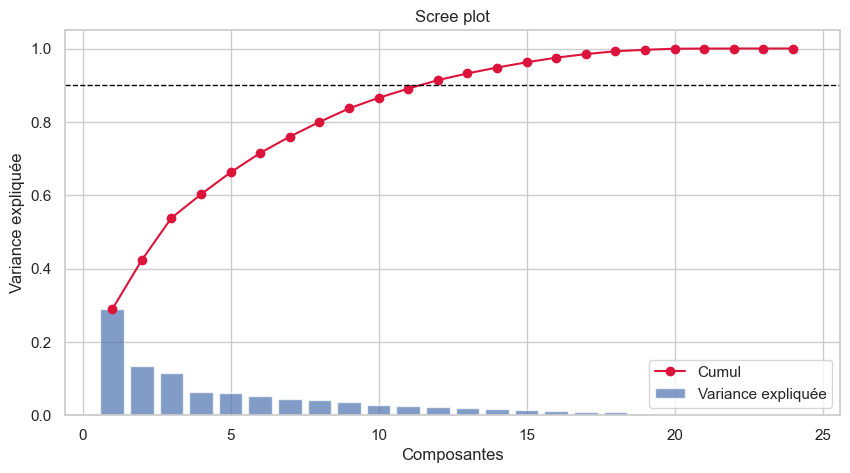

In [4]:
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, len(explained) + 1), explained, alpha=0.7, label="Variance expliquée")
ax.plot(range(1, len(explained) + 1), cumulative, marker="o", color="crimson", label="Cumul")
ax.axhline(0.90, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Composantes")
ax.set_ylabel("Variance expliquée")
ax.set_title("Scree plot")
ax.legend()
plt.show()


### Règle de Kaiser — Eigenvalues > 1

On repère ici les composantes dont l'**eigenvalue est supérieure à 1**. Ce critère donne un repère complémentaire au seuil de variance expliquée cumulée.

### Détail de la variance expliquée

On complète le scree plot par un affichage détaillé :
- variance expliquée par composante ;
- variance cumulée ;
- eigenvalue ;
- repère de Kaiser (`eigenvalue > 1`).

Dans cette version, on retient le premier nombre de composantes permettant d'atteindre **90 %** de variance expliquée cumulée.

In [5]:
variance_expliquee = pca_full.explained_variance_ratio_
variance_cumulee = np.cumsum(variance_expliquee)
eigenvalues = pca_full.explained_variance_

print('=== VARIANCE EXPLIQUEE ===')
for i, (var, cum, eigen) in enumerate(zip(variance_expliquee, variance_cumulee, eigenvalues)):
    kaiser = 'OK' if eigen > 1 else 'non'
    print(f'PC{i+1} : {var*100:.1f}% - Cumule : {cum*100:.1f}% - Eigenvalue : {eigen:.3f} - Kaiser : {kaiser}')

=== VARIANCE EXPLIQUEE ===
PC1 : 28.9% - Cumule : 28.9% - Eigenvalue : 6.977 - Kaiser : OK
PC2 : 13.4% - Cumule : 42.3% - Eigenvalue : 3.246 - Kaiser : OK
PC3 : 11.5% - Cumule : 53.8% - Eigenvalue : 2.776 - Kaiser : OK
PC4 : 6.5% - Cumule : 60.2% - Eigenvalue : 1.560 - Kaiser : OK
PC5 : 6.0% - Cumule : 66.2% - Eigenvalue : 1.447 - Kaiser : OK
PC6 : 5.3% - Cumule : 71.5% - Eigenvalue : 1.280 - Kaiser : OK
PC7 : 4.5% - Cumule : 76.0% - Eigenvalue : 1.076 - Kaiser : OK
PC8 : 4.0% - Cumule : 80.0% - Eigenvalue : 0.967 - Kaiser : non
PC9 : 3.7% - Cumule : 83.7% - Eigenvalue : 0.892 - Kaiser : non
PC10 : 2.9% - Cumule : 86.6% - Eigenvalue : 0.700 - Kaiser : non
PC11 : 2.5% - Cumule : 89.1% - Eigenvalue : 0.604 - Kaiser : non
PC12 : 2.3% - Cumule : 91.4% - Eigenvalue : 0.562 - Kaiser : non
PC13 : 1.8% - Cumule : 93.2% - Eigenvalue : 0.443 - Kaiser : non
PC14 : 1.6% - Cumule : 94.8% - Eigenvalue : 0.388 - Kaiser : non
PC15 : 1.4% - Cumule : 96.2% - Eigenvalue : 0.344 - Kaiser : non
PC16 : 1.3%

### Comparaison des seuils 80 % et 90 %

Avant de retenir le seuil final, on compare deux niveaux classiques de variance expliquée cumulée :
- **80 %** : solution plus compacte ;
- **90 %** : solution plus conservative, qui conserve davantage d'information.

L'objectif est de vérifier si la structure des clusters reste stable malgré ce changement de seuil.

In [6]:
threshold_rows = []
for threshold in [0.80, 0.90]:
    n_comp = int(np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= threshold) + 1)
    pca_test = PCA(n_components=n_comp)
    X_pca_test = pca_test.fit_transform(X_scaled)

    local_scores = []
    for n in range(3, 7):
        labels = KMeans(n_clusters=n, random_state=42, n_init=20).fit_predict(X_pca_test)
        local_scores.append((n, silhouette_score(X_pca_test, labels)))

    best_k, best_sil = sorted(local_scores, key=lambda x: x[1], reverse=True)[0]
    threshold_rows.append({
        'seuil_variance': f'{int(threshold * 100)}%',
        'n_composantes': n_comp,
        'variance_cumulee': pca_test.explained_variance_ratio_.sum(),
        'meilleur_k': best_k,
        'meilleure_silhouette': best_sil,
    })

threshold_comparison = pd.DataFrame(threshold_rows)
threshold_comparison

,seuil_variance,n_composantes,variance_cumulee,meilleur_k,meilleure_silhouette
0,80%,9,0.837,3,0.262
1,90%,12,0.914,3,0.242


Lecture de ce test de sensibilité :

- avec **80 %**, on obtient moins de composantes et la meilleure silhouette ;
- avec **90 %**, on conserve davantage d'information, avec une silhouette un peu plus faible ;
- dans les deux cas, **3 clusters** restent la meilleure solution selon la silhouette seule ;


In [7]:
loadings = pd.DataFrame(
    pca.components_.T * np.sqrt(pca.explained_variance_),
    index=features,
    columns=[f"PC{i}" for i in range(1, pca.n_components_ + 1)],
)
print("=== TOP VARIABLES PAR COMPOSANTE ===")
for col in loadings.columns:
    print(f"\n{col} :")
    top = loadings[col].abs().sort_values(ascending=False).head(6)
    for var, val in top.items():
        signe = "+" if loadings[col][var] > 0 else "-"
        print(f"  {signe} {var} : {val:.3f}")
#loadings


=== TOP VARIABLES PAR COMPOSANTE ===

PC1 :
  + proteines_animales_g_hab_jour : 0.896
  + pib_hab_ppp : 0.825
  + indice_gouvernance_moyen : 0.785
  + volaille_kcal_hab_jour : 0.773
  + volaille_kg_hab_an : 0.771
  + pct_population_urbaine : 0.764

PC2 :
  + marche_volaille_tonnes : 0.743
  + volaille_disponibilite_tonnes : 0.743
  + volaille_production_tonnes : 0.732
  + part_volaille_dans_consommation_viande : 0.547
  + part_proteines_volaille_dans_viandes : 0.537
  - score_stabilite_politique : 0.471

PC3 :
  + part_volaille_dans_consommation_viande : 0.747
  + part_proteines_volaille_dans_viandes : 0.743
  - marche_volaille_tonnes : 0.554
  - volaille_disponibilite_tonnes : 0.552
  - volaille_production_tonnes : 0.552
  + volaille_kg_hab_an : 0.432

PC4 :
  + volaille_import_tonnes : 0.595
  + taux_dependance_import : 0.585
  + croissance_population_urbaine_pct : 0.447
  - croissance_pib_pct : 0.428
  + variation_part_urbaine_points : 0.393
  - prix_moyen_import_volaille_usd_tonne 

## Interprétation des 12 composantes principales

L'ACP sert ici à résumer les variables commerciales en quelques axes plus lisibles avant le clustering.

| Composante | Variance | Nom | Variables clés | Interprétation |
|---|---:|---|---|---|
| `PC1` | `28,9 %` | Maturité du marché et niveau de vie | `proteines_animales_g_hab_jour`, `pib_hab_ppp`, `indice_gouvernance_moyen`, `volaille_kcal_hab_jour`, `volaille_kg_hab_an`, `pct_population_urbaine` | Oppose les marchés déjà matures, solvables, urbanisés et institutionnellement plus stables aux marchés plus fragiles ou moins structurés. |
| `PC2` | `13,4 %` | Taille du marché volaille | `marche_volaille_tonnes`, `volaille_disponibilite_tonnes`, `volaille_production_tonnes`, `part_volaille_dans_consommation_viande` | Met en avant les pays qui se distinguent d'abord par le volume total de leur marché volaille. |
| `PC3` | `11,5 %` | Place relative de la volaille dans l'alimentation | `part_volaille_dans_consommation_viande`, `part_proteines_volaille_dans_viandes`, `volaille_kg_hab_an` | Distingue les pays où la volaille pèse fortement dans la consommation carnée de ceux où elle reste plus secondaire. |
| `PC4` | `6,5 %` | Dépendance import et pression de demande | `volaille_import_tonnes`, `taux_dependance_import`, `croissance_population_urbaine_pct`, `variation_part_urbaine_points` | Fait ressortir les marchés dont l'offre dépend davantage des importations et où la pression de demande peut croître. |
| `PC5` | `6,0 %` | Prix d'importation et montée de la demande | `prix_moyen_import_volaille_usd_tonne`, `croissance_import_volaille_pct`, `croissance_conso_volaille_pct`, `variation_part_urbaine_points` | Isole les marchés où la demande progresse avec un signal prix plus marqué sur la volaille importée. |
| `PC6` | `5,3 %` | Dynamique récente de consommation volaille | `croissance_conso_volaille_pct`, `croissance_import_volaille_pct`, `taux_dependance_import` | Sert à repérer les pays où la demande récente évolue le plus rapidement. |
| `PC7` | `4,5 %` | Croissance économique et fragilité alimentaire | `croissance_pib_pct`, `cout_alimentation_saine_ppp_jour`, `sous_alimentation_pct`, `variation_part_urbaine_points` | Oppose les pays en progression économique relative à ceux qui restent plus contraints sur le plan alimentaire. |
| `PC8` | `4,0 %` | Accessibilité économique et risque pays | `cout_alimentation_saine_ppp_jour`, `score_stabilite_politique`, `prevalence_inabordabilite_alimentation_saine_pct` | Informe sur la contrainte économique qui pèse sur la consommation, avec une nuance liée au risque pays. |
| `PC9` | `3,7 %` | Ouverture alimentaire et sensibilité commerciale | `imports_alimentaires_pct`, `prix_moyen_import_volaille_usd_tonne`, `taux_dependance_import` | Apporte une lecture complémentaire sur l'ouverture du marché et sa sensibilité aux importations. |
| `PC10` | `2,9 %` | Exposition commerciale secondaire | `imports_alimentaires_pct`, `prix_moyen_import_volaille_usd_tonne`, `volaille_import_tonnes` | Nuance les différences entre marchés selon leur niveau de prix à l'importation et leur exposition commerciale. |
| `PC11` | `2,5 %` | Tensions de croissance de court terme | `croissance_conso_volaille_pct`, `croissance_import_volaille_pct`, `croissance_pib_pct` | Rend visibles des écarts plus fins dans la dynamique récente de marché. |
| `PC12` | `2,3 %` | Nuances secondaires de structure commerciale | `imports_alimentaires_pct`, `score_stabilite_politique`, `croissance_pib_pct`, `pct_population_urbaine` | Complète la lecture avec des différences de second ordre entre pays proches sur les axes principaux. |

En pratique, les premières composantes résument surtout :
1. le **niveau de maturité commerciale** du marché ;
2. la **taille du débouché volaille** ;
3. la **place réelle de la volaille dans les habitudes alimentaires** ;
4. la **dépendance aux importations** et la **dynamique de demande**.


## 3. Analyse du cercle des corrélations

## Légende des couleurs - familles de variables

| Couleur | Famille | Variables |
|---|---|---|
| 🔴 Rouge | Volaille - consommation | `volaille_kcal_hab_jour`, `volaille_kg_hab_an`, `part_volaille_dans_consommation_viande`, `part_proteines_volaille_dans_viandes` |
| 🟥 Rouge fonce | Volaille - volumes | `volaille_production_tonnes`, `volaille_import_tonnes`, `volaille_disponibilite_tonnes`, `marche_volaille_tonnes` |
| 🟢 Vert | Economie et commerce | `pib_hab_ppp`, `croissance_pib_pct`, `imports_alimentaires_pct`, `taux_dependance_import`, `prix_moyen_import_volaille_usd_tonne` |
| 🔵 Bleu | Démographie et urbanisation | `pct_population_urbaine`, `croissance_population_urbaine_pct`, `variation_part_urbaine_points` |
| 🟣 Violet | Risque pays et gouvernance | `score_stabilite_politique`, `indice_gouvernance_moyen` |
| 🟠 Orange | Alimentation et accessibilité | `proteines_animales_g_hab_jour`, `sous_alimentation_pct`, `cout_alimentation_saine_ppp_jour`, `prevalence_inabordabilite_alimentation_saine_pct` |
| 🟦 Turquoise | Dynamique récente | `croissance_conso_volaille_pct`, `croissance_import_volaille_pct` |


In [8]:
# Couleurs par famille de variables
feature_colors = {
    'volaille_kcal_hab_jour': '#e74c3c',
    'volaille_kg_hab_an': '#e74c3c',
    'part_volaille_dans_consommation_viande': '#e74c3c',
    'part_proteines_volaille_dans_viandes': '#e74c3c',
    'volaille_production_tonnes': '#c0392b',
    'volaille_import_tonnes': '#c0392b',
    'volaille_disponibilite_tonnes': '#c0392b',
    'marche_volaille_tonnes': '#c0392b',
    'pib_hab_ppp': '#27ae60',
    'croissance_pib_pct': '#27ae60',
    'imports_alimentaires_pct': '#27ae60',
    'taux_dependance_import': '#27ae60',
    'prix_moyen_import_volaille_usd_tonne': '#27ae60',
    'pct_population_urbaine': '#3498db',
    'croissance_population_urbaine_pct': '#3498db',
    'variation_part_urbaine_points': '#3498db',
    'score_stabilite_politique': '#9b59b6',
    'indice_gouvernance_moyen': '#9b59b6',
    'proteines_animales_g_hab_jour': '#e67e22',
    'sous_alimentation_pct': '#e67e22',
    'cout_alimentation_saine_ppp_jour': '#e67e22',
    'prevalence_inabordabilite_alimentation_saine_pct': '#e67e22',
    'croissance_conso_volaille_pct': '#16a085',
    'croissance_import_volaille_pct': '#16a085',
}

feature_groups = {
    'Volaille - consommation': ['volaille_kcal_hab_jour', 'volaille_kg_hab_an', 'part_volaille_dans_consommation_viande', 'part_proteines_volaille_dans_viandes'],
    'Volaille - volumes': ['volaille_production_tonnes', 'volaille_import_tonnes', 'volaille_disponibilite_tonnes', 'marche_volaille_tonnes'],
    'Economie et commerce': ['pib_hab_ppp', 'croissance_pib_pct', 'imports_alimentaires_pct', 'taux_dependance_import', 'prix_moyen_import_volaille_usd_tonne'],
    'Demographie et urbanisation': ['pct_population_urbaine', 'croissance_population_urbaine_pct', 'variation_part_urbaine_points'],
    'Risque pays et gouvernance': ['score_stabilite_politique', 'indice_gouvernance_moyen'],
    'Alimentation et accessibilite': ['proteines_animales_g_hab_jour', 'sous_alimentation_pct', 'cout_alimentation_saine_ppp_jour', 'prevalence_inabordabilite_alimentation_saine_pct'],
    'Dynamique recente': ['croissance_conso_volaille_pct', 'croissance_import_volaille_pct'],
}

def plot_correlation_circle(loadings_df, pc_x=1, pc_y=2):
    from matplotlib.patches import Patch

    fig, ax = plt.subplots(figsize=(12, 12))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('#f8f9fa')

    ax.axhline(0, color='#7f8c8d', linewidth=1, alpha=0.6)
    ax.axvline(0, color='#7f8c8d', linewidth=1, alpha=0.6)

    circle_outer = plt.Circle((0, 0), 1, fill=False, color='#2c3e50', linewidth=2)
    circle_mid = plt.Circle((0, 0), 0.5, fill=False, color='#bdc3c7', linewidth=1.2, linestyle=':')
    ax.add_patch(circle_outer)
    ax.add_patch(circle_mid)

    x_col = f'PC{pc_x}'
    y_col = f'PC{pc_y}'

    for feature, row in loadings_df[[x_col, y_col]].iterrows():
        x = row[x_col]
        y = row[y_col]
        color = feature_colors.get(feature, 'steelblue')
        ax.annotate(
            '',
            xy=(x, y),
            xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color=color, lw=2, mutation_scale=14),
        )

        norm = np.sqrt(x**2 + y**2)
        if norm > 0:
            label_x = x + (x / norm) * 0.10
            label_y = y + (y / norm) * 0.10
        else:
            label_x, label_y = x, y

        ax.text(
            label_x,
            label_y,
            feature,
            fontsize=8,
            color=color,
            ha='center',
            va='center',
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor=color, alpha=0.9, linewidth=1),
        )

    legend_elements = [
        Patch(facecolor='#e74c3c', label='Volaille - consommation'),
        Patch(facecolor='#c0392b', label='Volaille - volumes'),
        Patch(facecolor='#27ae60', label='Economie et commerce'),
        Patch(facecolor='#3498db', label='Démographie et urbanisation'),
        Patch(facecolor='#9b59b6', label='Risque pays et gouvernance'),
        Patch(facecolor='#e67e22', label='Alimentation et accessibilité'),
        Patch(facecolor='#16a085', label='Dynamique récente'),
    ]
    ax.legend(handles=legend_elements, loc='lower left', fontsize=9, framealpha=0.95, edgecolor='#bdc3c7', fancybox=True)

    ax.set_xlim(-1.25, 1.25)
    ax.set_ylim(-1.25, 1.25)
    ax.set_title(f'Cercle des corrélations - {x_col} vs {y_col}', fontsize=14, fontweight='bold')
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_aspect('equal')
    ax.grid(False)
    plt.show()

#fonction nuage de points
def plot_individual_projection(pca_df, x_col='PC1', y_col='PC2', n_labels=14):
    fig, ax = plt.subplots(figsize=(11, 8))
    ax.set_facecolor('#f8f9fa')

    sns.scatterplot(
        data=pca_df,
        x=x_col,
        y=y_col,
        ax=ax,
        color='#4c78a8',
        s=45,
        alpha=0.75,
        edgecolor='white',
        linewidth=0.4
    )

    ax.axhline(0, color='#7f8c8d', linewidth=1, alpha=0.6)
    ax.axvline(0, color='#7f8c8d', linewidth=1, alpha=0.6)

    for _, row in pca_df.iterrows():
        ax.text(
            row[x_col] + 0.03,
            row[y_col] + 0.03,
            row['pays'],
            fontsize=7,
            color='#2c3e50'
        )

    ax.set_title(f'Projection des individus - {x_col} vs {y_col}', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.2)
    plt.show()


## Analyse du cercle des corrélations - PC1 vs PC2

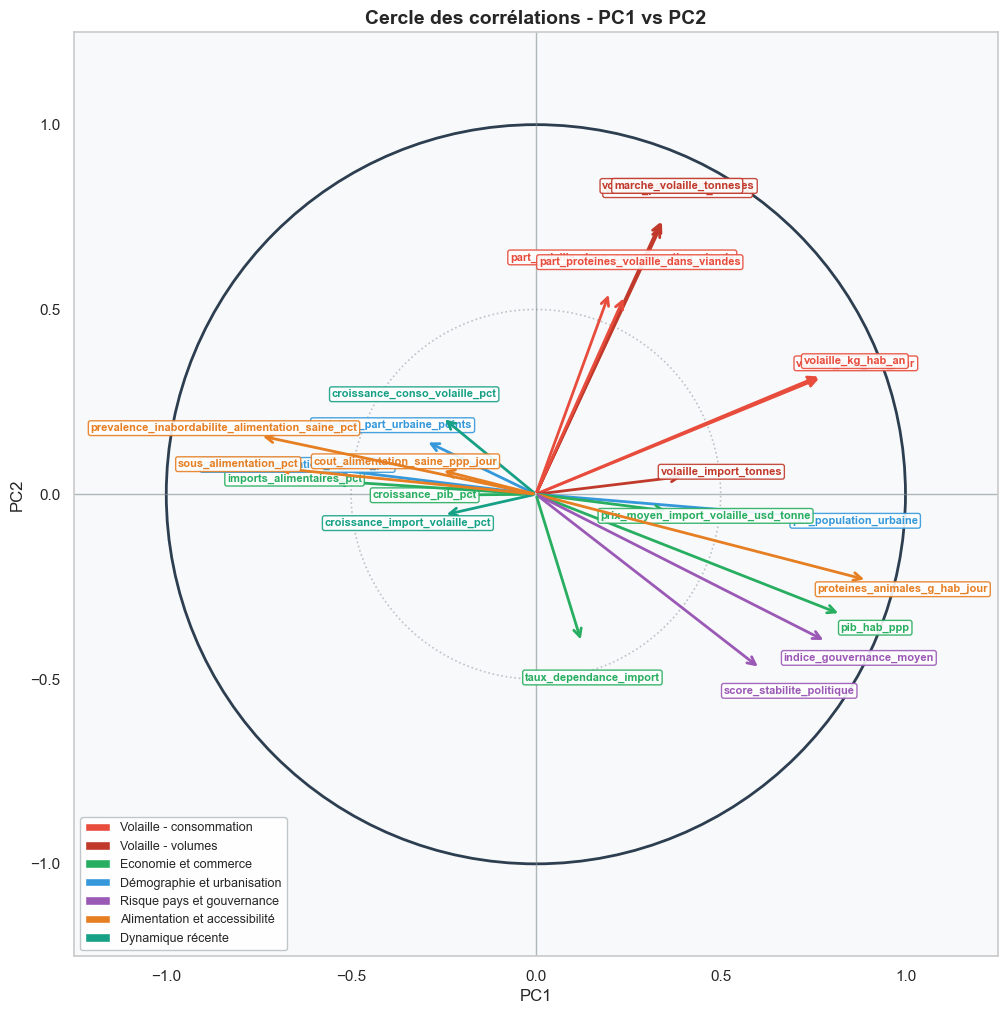

In [9]:
plot_correlation_circle(loadings, 1, 2)

#### Interprétation du cercle - PC1 vs PC2

- **PC1** porte surtout un axe de **maturité commerciale et de niveau de vie** : on y retrouve surtout `proteines_animales_g_hab_jour`, `pib_hab_ppp`, `indice_gouvernance_moyen`, `volaille_kcal_hab_jour`, `volaille_kg_hab_an` et `pct_population_urbaine`.
- **PC2** porte davantage un axe de **taille de marché volaille** : `marche_volaille_tonnes`, `volaille_disponibilite_tonnes`, `volaille_production_tonnes` et, dans une moindre mesure, `part_volaille_dans_consommation_viande`.
- Dans ce plan, on peut donc lire assez simplement :
  - **à droite** : pays plus solvables, plus urbanisés et plus matures commercialement ;
  - **en haut** : pays avec un marché volaille plus massif.
- Ce plan est le plus utile pour séparer les pays qui cumulent **volume de marché** et **solidité commerciale générale**.


### Projection des individus - PC1 vs PC2

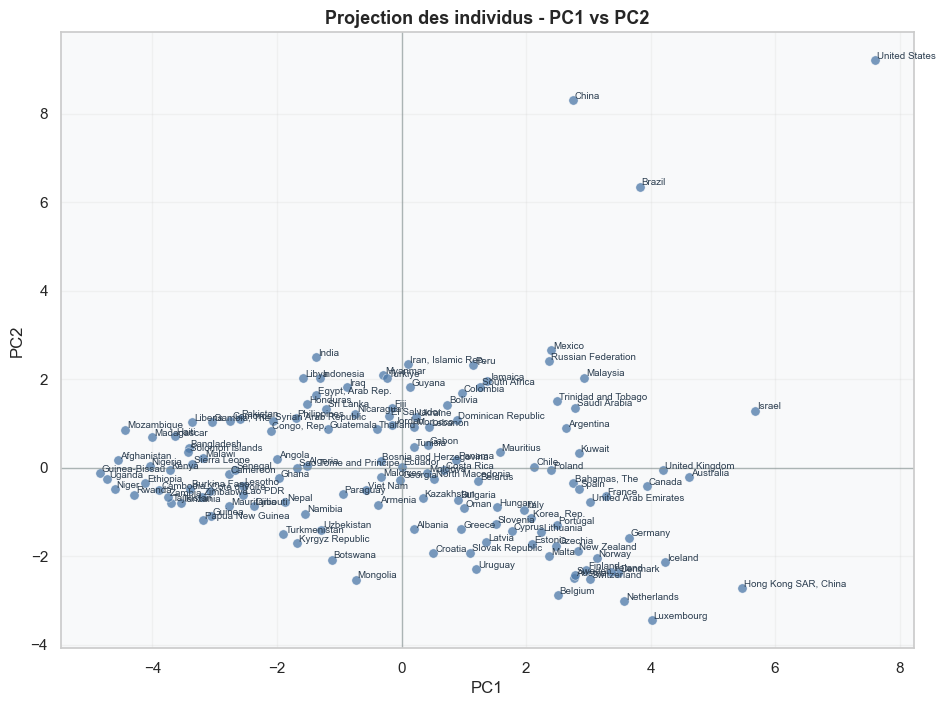

In [10]:
pca_df = pd.DataFrame(X_pca[:, :3], columns=['PC1', 'PC2', 'PC3'])
pca_df['pays'] = df['pays'].values
plot_individual_projection(pca_df, 'PC1', 'PC2')

#### Interprétation des pays - PC1 vs PC2

- **Etats-Unis** et **Chine** ressortent très fortement, mais pour des raisons un peu différentes :
  - les **Etats-Unis** cumulent taille de marché et maturité commerciale ;
  - la **Chine** ressort surtout par la masse du marché.
- Des pays comme **Pays-Bas**, **Allemagne**, **Belgique** ou **Royaume-Uni** apparaissent davantage comme des marchés matures, solvables et bien urbanisés.
- A l'inverse, des pays plus à gauche comme **Cambodge** semblent moins favorables sur l'axe de maturité commerciale générale.
- Ce plan est très utile pour repérer le compromis entre **gros marché** et **environnement commercial favorable**.


## Analyse PC1 vs PC3

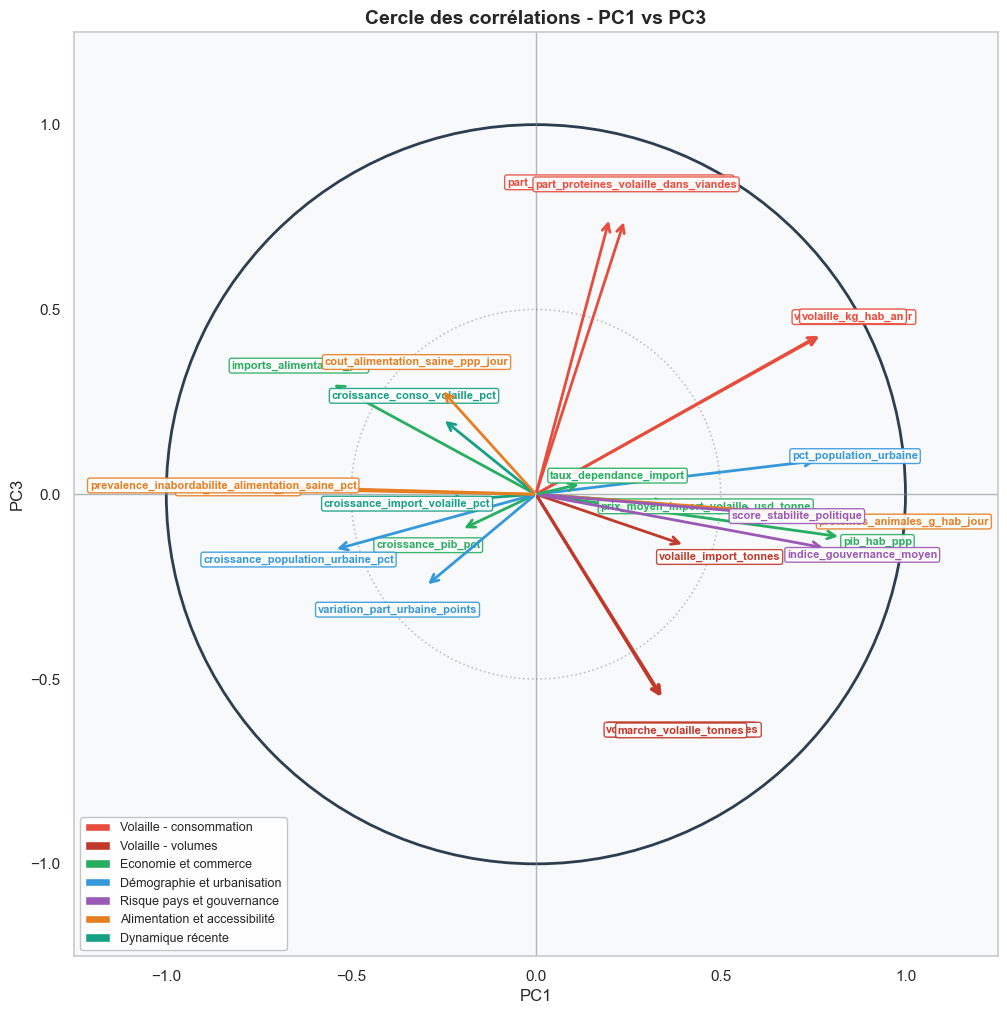

In [11]:
plot_correlation_circle(loadings, 1, 3)

#### Interprétation du cercle - PC1 vs PC3

- **PC1** reste l'axe de maturité commerciale et de niveau de vie.
- **PC3** capte davantage une logique de **spécialisation volaille dans les habitudes de consommation**, avec `part_volaille_dans_consommation_viande`, `part_proteines_volaille_dans_viandes`, `volaille_kg_hab_an` et `volaille_kcal_hab_jour`.
- Ce plan permet donc de distinguer :
  - des pays commercialement matures ;
  - et, en plus, des pays où la volaille occupe déjà une place forte dans la consommation carnée.
- C'est un plan utile pour repérer des marchés qui ne sont pas seulement solvables, mais aussi déjà bien alignés avec le produit.


### Projection des individus - PC1 vs PC3

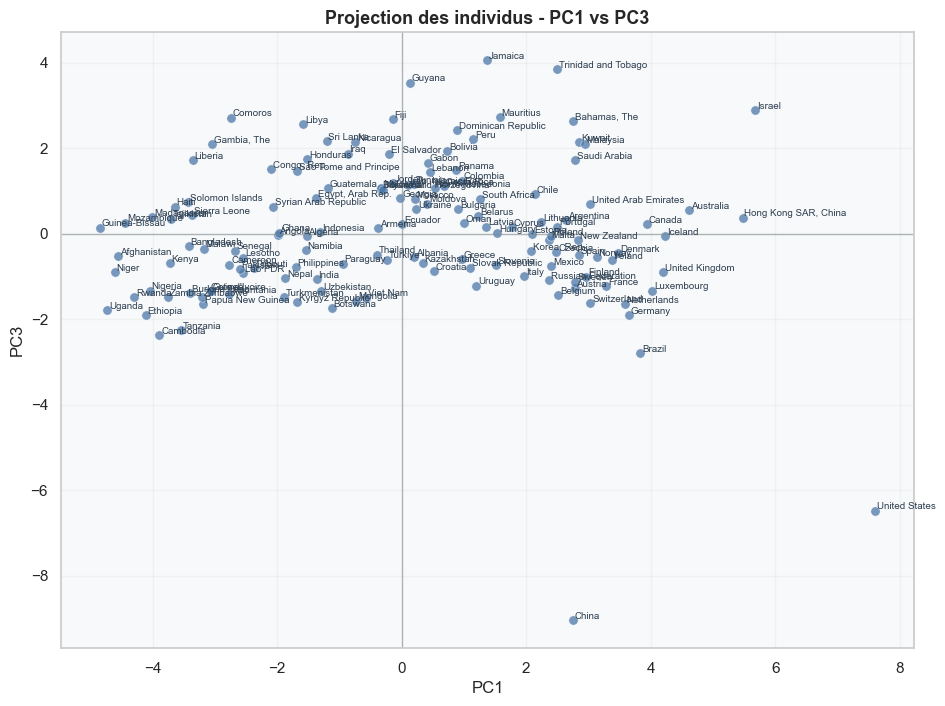

In [12]:
plot_individual_projection(pca_df, 'PC1', 'PC3')

#### Interprétation des pays - PC1 vs PC3

- Des pays comme **Pays-Bas**, **Allemagne** ou **Belgique** ressortent positivement sur `PC3`, ce qui suggère un profil de consommation plus favorable à la volaille.
- **Israel** ressort plutôt à l'opposé sur cet axe, ce qui invite à regarder de plus près la structure exacte de la consommation.
- **Chine** garde une position marquante, avec un poids de marché fort et un signal positif sur `PC3`.
- Ce plan aide à distinguer les pays simplement riches et matures, des pays où la **volaille semble déjà bien installée** dans les habitudes alimentaires.


## Analyse PC2 vs PC3

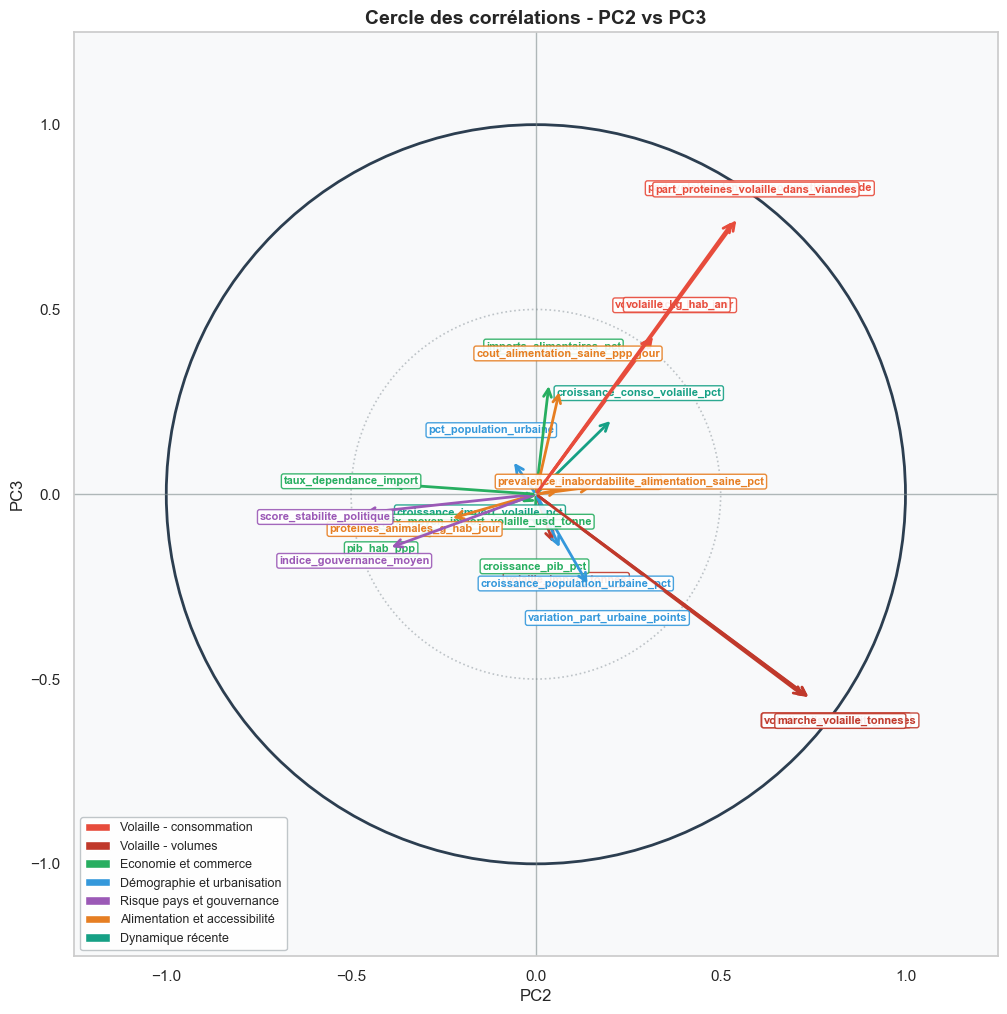

In [13]:
plot_correlation_circle(loadings, 2, 3)

#### Interprétation du cercle - PC2 vs PC3

- **PC2** garde une logique de **volume de marché**.
- **PC3** garde une logique de **profil de consommation volaille**.
- Ce plan oppose donc plutôt :
  - la **taille absolue du marché** ;
  - et la **place relative de la volaille dans l'alimentation**.
- Il est utile pour éviter de confondre un très grand marché peu spécialisé avec un marché plus modeste mais déjà très orienté volaille.


### Projection des individus - PC2 vs PC3

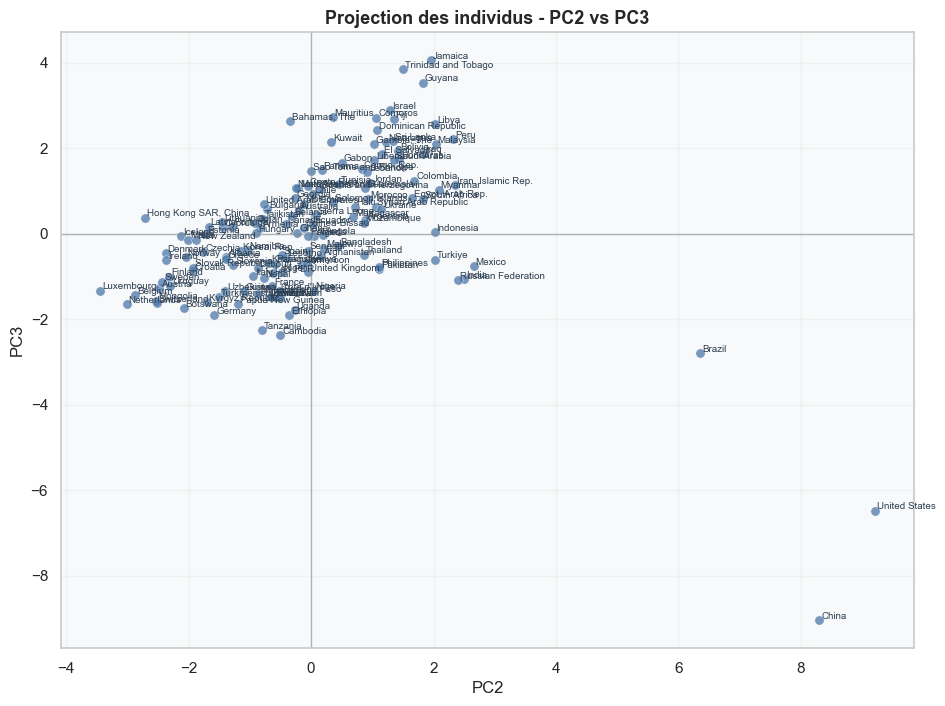

In [14]:
plot_individual_projection(pca_df, 'PC2', 'PC3')

#### Interprétation des pays - PC2 vs PC3

- **Chine**, **Etats-Unis** et **Brésil** ressortent d'abord par la **taille du marché**.
- Des pays comme **Pays-Bas**, **Belgique** ou **Luxembourg** semblent moins dominants en volume, mais plus marqués sur la dimension de **profil de consommation volaille**.
- Ce plan est particulièrement utile pour séparer :
  - les **géants de marché** ;
  - et les pays plus petits mais potentiellement plus alignés avec une offre spécialisée volaille.


## 5. Classification ascendante hiérarchique (CAH)

La classification ascendante hiérarchique permet de partir d'une lecture structurelle des pays avant de passer à K-means. Le dendrogramme aide ici à repérer les grandes fusions entre groupes et à identifier une coupure plausible du nombre de clusters.

### Analyse des sauts de distance - lecture du dendrogramme

Le dendrogramme permet de visualiser les fusions successives entre groupes de pays.
On l'utilise ici comme repère complémentaire au score de silhouette :
- plus le saut final est important, plus la coupure choisie est défendable ;
- la lecture visuelle vient confirmer ou nuancer le choix statistique de `k`.


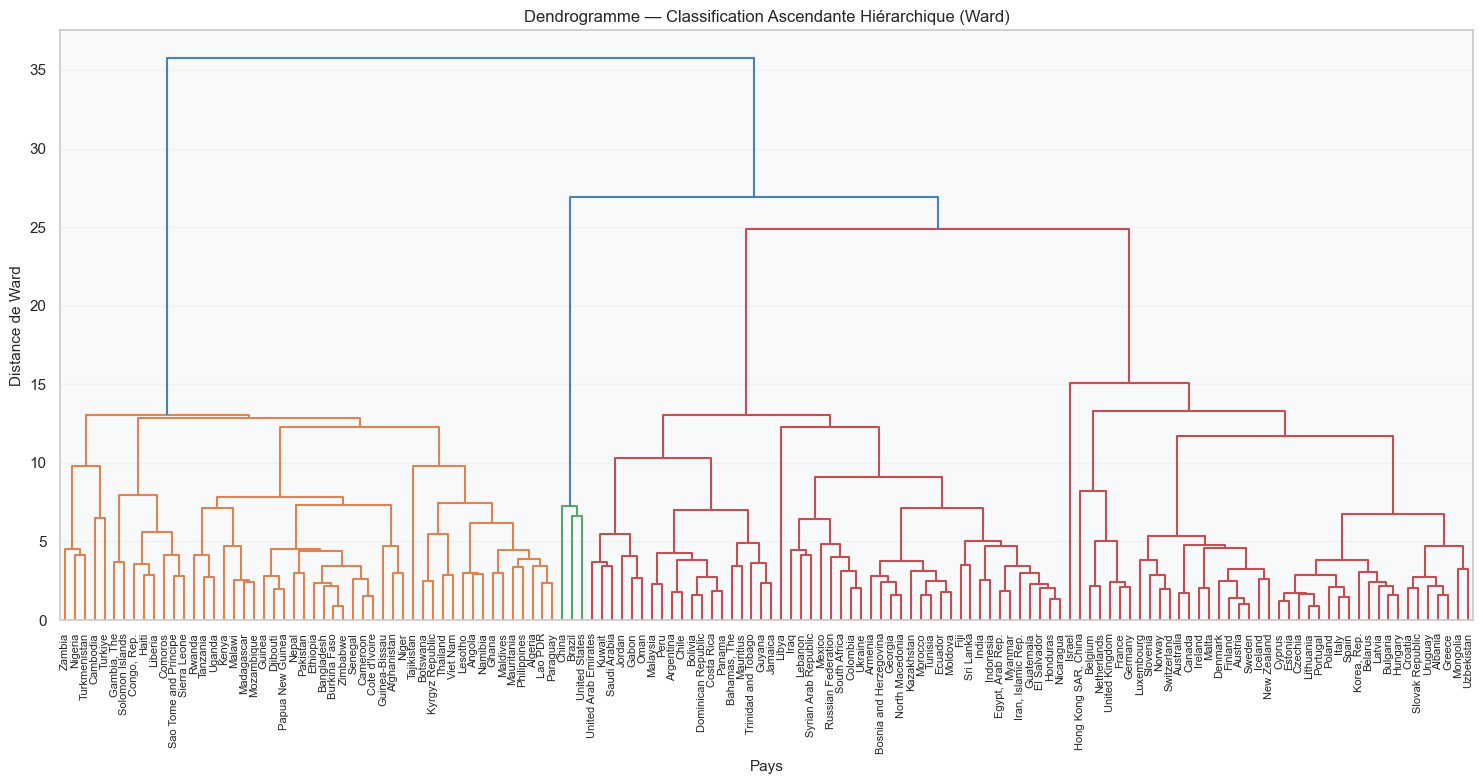

In [15]:
# ============================================================
# CAH — CLASSIFICATION ASCENDANTE HIÉRARCHIQUE
# ============================================================

# Le choix final retient 4 clusters en croisant la silhouette,
# la technique du coude et l'analyse du dendrogramme.
n_clusters = 4

# Calcul de la matrice de liens avec la méthode de Ward
Z = linkage(X_pca, method="ward")

# Dendrogramme
fig, ax = plt.subplots(figsize=(15, 8))
fig.patch.set_facecolor('white')

dendrogram(Z, 
    labels=df["pays"].tolist(),
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=None,
    above_threshold_color='steelblue',
    ax=ax)

plt.title("Dendrogramme — Classification Ascendante Hiérarchique (Ward)")
ax.set_xlabel('Pays', fontsize=11)
ax.set_ylabel('Distance de Ward', fontsize=11)
ax.set_facecolor('#f8f9fa')
ax.grid(axis='y', alpha=0.2)
ax.grid(False, axis='x')

plt.tight_layout()
plt.show()

labels_cah = fcluster(Z, t=n_clusters, criterion="maxclust")


In [16]:
distances = Z[-7:, 2] #-7 = indice de démarrage, 2 = indice de fin

rows = []
prev_distance = distances[0]
current_clusters = len(distances)

for distance in distances[1:]:
    jump = distance - prev_distance
    rows.append({
        "Fusion": f"{current_clusters} clusters -> {current_clusters - 1}",
        "Distance": round(distance, 2),
        "Saut_val": round(jump, 2),
    })
    current_clusters -= 1
    prev_distance = distance

jump_df = pd.DataFrame(rows)

max_jump = jump_df["Saut_val"].max()
jump_df["Saut"] = jump_df["Saut_val"].apply(
    lambda x: f"+{x:.2f} -> Grand saut ✅" if x == max_jump else f"+{x:.2f}"
)

jump_df = jump_df[["Fusion", "Distance", "Saut"]]
jump_df

,Fusion,Distance,Saut
0,7 clusters -> 6,13.070,+0.05
1,6 clusters -> 5,13.330,+0.26
2,5 clusters -> 4,15.060,+1.73
3,4 clusters -> 3,24.890,+9.83 -> Grand saut ✅
4,3 clusters -> 2,26.930,+2.04
5,2 clusters -> 1,35.730,+8.80


L'analyse des sauts du dendrogramme suggèrent une structuration plus naturelle en **4 groupes** en se basant sur la plus grande distance de saut.

## 6. K-means - test des partitions puis stabilisation

Après la lecture hiérarchique du dendrogramme, on utilise K-means pour comparer plusieurs valeurs de `k` avec des indicateurs quantitatifs complémentaires : silhouette, inertie et équilibre des tailles de clusters.

In [17]:
scores = []
for n in range(2, 8):
    kmeans = KMeans(n_clusters=n, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_pca)
    sil = silhouette_score(X_pca, labels)
    cluster_sizes = pd.Series(labels).value_counts()
    scores.append({
        'n_clusters': n,
        'silhouette': sil,
        'taille_min_cluster': int(cluster_sizes.min()),
        'taille_max_cluster': int(cluster_sizes.max()),
        'inertie': kmeans.inertia_
    })

scores_df = pd.DataFrame(scores).sort_values('n_clusters').reset_index(drop=True)
scores_df

,n_clusters,silhouette,taille_min_cluster,taille_max_cluster,inertie
0,2,0.224,60,82,"2,408.228"
1,3,0.242,3,79,"2,048.531"
2,4,0.202,3,51,"1,755.693"
3,5,0.200,3,50,"1,645.277"
4,6,0.192,1,45,"1,538.843"
5,7,0.160,1,42,"1,470.175"


### Comparaison — K-means sur données brutes standardisées

Pour vérifier que la segmentation ne dépend pas uniquement de l'ACP, on teste ici un **K-means directement sur les données d'origine**, après imputation et standardisation.

L'idée n'est pas de remplacer l'approche ACP, mais de contrôler si la structure générale reste cohérente sans réduction de dimension.

In [18]:
# K-means sur données brutes standardisées (sans ACP)
X_brute = df[MODELING_FEATURES].copy()

imputer_brute = SimpleImputer(strategy='median')
scaler_brute = StandardScaler()

X_brute_imputed = imputer_brute.fit_transform(X_brute)
X_brute_scaled = scaler_brute.fit_transform(X_brute_imputed)

scores_brute = []
for n in range(2, 8):
    kmeans_brute = KMeans(n_clusters=n, random_state=42, n_init=20)
    labels_brute = kmeans_brute.fit_predict(X_brute_scaled)
    sil_brute = silhouette_score(X_brute_scaled, labels_brute)
    cluster_sizes_brute = pd.Series(labels_brute).value_counts()
    scores_brute.append({
        'n_clusters': n,
        'silhouette_brute': sil_brute,
        'taille_min_cluster_brute': int(cluster_sizes_brute.min()),
        'taille_max_cluster_brute': int(cluster_sizes_brute.max()),
        'inertie_brute': kmeans_brute.inertia_,
    })

scores_brute_df = pd.DataFrame(scores_brute).sort_values('n_clusters').reset_index(drop=True)
scores_brute_df

,n_clusters,silhouette_brute,taille_min_cluster_brute,taille_max_cluster_brute,inertie_brute
0,2,0.203,60,82,"2,701.308"
1,3,0.219,3,78,"2,340.383"
2,4,0.176,3,48,"2,047.618"
3,5,0.150,3,40,"1,931.767"
4,6,0.154,3,39,"1,826.882"
5,7,0.145,1,44,"1,734.910"


In [19]:
# Comparaison ACP vs données brutes standardisées
comparison_kmeans = scores_df.merge(scores_brute_df, on='n_clusters', how='left')
comparison_kmeans

,n_clusters,silhouette,taille_min_cluster,taille_max_cluster,inertie,silhouette_brute,taille_min_cluster_brute,taille_max_cluster_brute,inertie_brute
0,2,0.224,60,82,"2,408.228",0.203,60,82,"2,701.308"
1,3,0.242,3,79,"2,048.531",0.219,3,78,"2,340.383"
2,4,0.202,3,51,"1,755.693",0.176,3,48,"2,047.618"
3,5,0.200,3,50,"1,645.277",0.150,3,40,"1,931.767"
4,6,0.192,1,45,"1,538.843",0.154,3,39,"1,826.882"
5,7,0.160,1,42,"1,470.175",0.145,1,44,"1,734.910"


Lecture de cette comparaison :

- les colonnes sans suffixe correspondent au **K-means sur scores ACP** ;
- les colonnes suffixées par `_brute` correspondent au **K-means sur données brutes standardisées** ;
- si les résultats restent proches, cela renforce la robustesse de la segmentation ;
- si les résultats divergent fortement, cela montre que la réduction de dimension par ACP change davantage la structure du problème.

Dans notre cas, cette comparaison permet surtout de montrer que l'ACP n'a pas été utilisée par automatisme, mais comme un choix méthodologique assumé et vérifié.

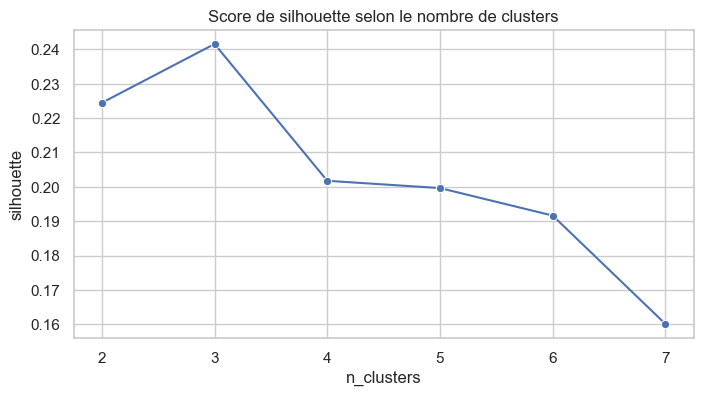

Nombre de clusters retenu pour la silhouette : 3


In [20]:
plt.figure(figsize=(8, 4))
sns.lineplot(data=scores_df, x='n_clusters', y='silhouette', marker='o')
plt.title('Score de silhouette selon le nombre de clusters')
plt.show()

print(f'Nombre de clusters retenu pour la silhouette : 3')

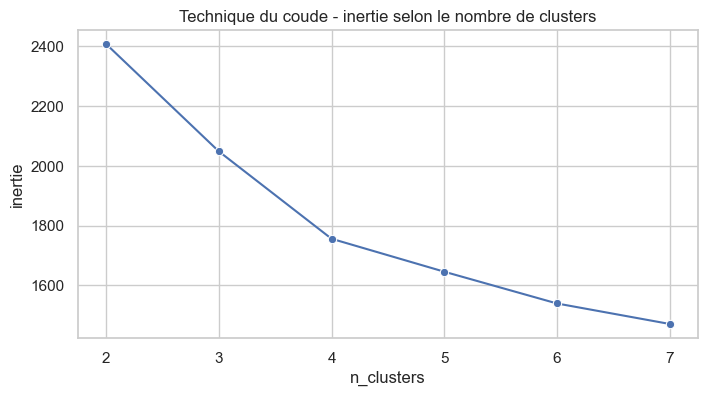

Nombre de clusters retenu pour le coude : 4


In [21]:
plt.figure(figsize=(8, 4))
sns.lineplot(data=scores_df, x='n_clusters', y='inertie', marker='o')
plt.title("Technique du coude - inertie selon le nombre de clusters")
plt.show()

print(f'Nombre de clusters retenu pour le coude : 4')

Nombre de clusters ressortant des analyses :

Silhouette  = 3 

Coude = 4 

Dendrogramme = 4 


La silhouette favorise **3 clusters**, tandis que la technique du coude confirme une hésitation entre **3** et **4**. En cohérence avec la CAH et la lecture des sauts du dendrogramme, nous retenons finalement **4 clusters** pour la suite de l'analyse.

## 7. Resultats K-means - 4 clusters finaux

La comparaison CAH / K-means permet de vérifier que la segmentation reste globalement cohérente d'une méthode à l'autre.

L'ARI calculé plus haut donne une mesure synthétique de cet accord, tandis que le tableau croisé permet d'identifier les groupes les plus stables.

**Important :** les numéros attribués par K-means sont **arbitraires**. D'un lancement à l'autre ou d'un autre paramétrage à l'autre, les groupes peuvent garder la même structure tout en changeant de numéro. Dans ce notebook, on conserve donc les **identifiants bruts** de K-means dans les graphiques et les tableaux. L'interprétation métier des clusters est faite séparément, sans supposer qu'un numéro précis porte toujours le même profil.


In [22]:
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
labels_kmeans = kmeans.fit_predict(X_pca)

df_clusters = df.copy()
df_clusters["cluster_cah"] = labels_cah
df_clusters["cluster_kmeans"] = labels_kmeans + 1

sil_final = silhouette_score(X_pca, labels_kmeans)
ari = adjusted_rand_score(labels_cah, labels_kmeans + 1)

print(f"Silhouette K-means : {sil_final:.3f}")
print(f"Accord CAH / K-means (ARI) : {ari:.3f}")
df_clusters.head()

Silhouette K-means : 0.202
Accord CAH / K-means (ARI) : 0.728


,pays,iso3,continent,landlocked,distance_france_km,population_totale,population_milliers,croissance_population_pct,croissance_population_urbaine_pct,variation_part_urbaine_points,croissance_conso_volaille_pct,croissance_import_volaille_pct,volaille_kcal_hab_jour,volaille_kg_hab_an,viande_totale_kg_hab_an,proteines_volaille_g_hab_jour,proteines_viande_totale_g_hab_jour,proteines_animales_g_hab_jour,volaille_production_tonnes,volaille_import_tonnes,volaille_disponibilite_tonnes,volaille_import_quantite_trade_tonnes,volaille_export_quantite_trade_tonnes,volaille_import_valeur_kusd,volaille_export_valeur_kusd,prix_moyen_import_volaille_usd_tonne,prix_moyen_export_volaille_usd_tonne,pib_hab_ppp,croissance_pib_pct,pct_population_urbaine,imports_alimentaires_pct,sous_alimentation_pct,suffisance_apports_energetiques_pct,cout_alimentation_saine_ppp_jour,prevalence_inabordabilite_alimentation_saine_pct,nua_millions,lpi_douane,lpi_infrastructure,delai_import_jours,delai_export_jours,connectivite_maritime,importations_marchandises_usd,exportations_marchandises_usd,score_stabilite_politique,score_efficacite_gouvernement,score_qualite_reglementaire,score_etat_droit,score_controle_corruption,indice_gouvernance_moyen,marche_volaille_tonnes,taux_dependance_import,part_volaille_dans_consommation_viande,part_proteines_volaille_dans_viandes,cluster_cah,cluster_kmeans
0,Afghanistan,AFG,Asia,1.000,"5,489.888","35,688,935.000","35,688.935",2.983,4.165,1.028,-3.914,-11.836,6.770,1.790,9.500,0.810,4.250,12.200,28.000,29.000,64.000,"28,937.000",36.990,"28,934.000",31.040,999.896,839.146,"2,335.796",2.647,24.835,36.793,20.500,107.000,NaN,NaN,NaN,1.871,1.823,NaN,NaN,NaN,"7,065,000,000.000","723,000,000.000",21.244,23.299,32.523,29.512,16.612,24.638,"63,883.194",0.453,0.188,0.191,1,2
1,Albania,ALB,Europe,0.000,"1,461.321","2,648,285.000","2,648.285",-1.531,-0.777,1.682,-5.164,-4.456,43.930,11.470,42.750,5.240,18.640,62.900,13.000,20.000,33.000,"18,041.850",NaN,"17,062.560",NaN,945.721,NaN,"14,110.683",3.283,55.980,14.858,4.400,134.000,3.040,29.200,0.800,2.292,2.135,14.000,10.000,4.010,"5,271,000,000.000","2,292,000,000.000",68.693,56.319,56.606,53.424,36.391,54.286,"30,375.829",0.606,0.268,0.281,4,4
2,Algeria,DZA,Africa,0.000,"1,158.292","41,689,299.000","41,689.299",2.067,2.935,2.376,-1.810,-9.640,25.630,6.860,20.080,3.130,8.880,29.200,284.000,2.000,286.000,"2,407.740","1,520.270","5,193.750",372.340,"2,157.106",244.917,"13,493.561",1.500,71.323,20.230,2.900,146.000,4.100,41.300,17.200,2.249,2.499,5.000,4.000,12.278,"46,059,000,000.000","35,191,000,000.000",50.017,41.168,39.944,42.032,36.915,42.015,"285,988.591",0.007,0.342,0.352,1,2
3,Angola,AGO,Africa,0.000,"6,363.600","30,234,839.000","30,234.839",3.468,4.890,2.952,-7.302,-5.133,39.480,10.500,24.560,4.760,10.350,17.900,40.000,277.000,318.000,"277,796.200",868.290,"314,314.850",713.280,"1,131.458",821.477,"8,006.837",-0.149,65.085,17.735,15.200,115.000,3.180,60.100,18.200,1.683,1.997,14.000,14.000,25.089,"14,463,000,000.000","34,613,000,000.000",56.718,32.516,36.253,34.045,19.095,35.726,"317,465.809",0.871,0.428,0.460,1,2
4,Argentina,ARG,America,0.000,"10,921.860","44,288,894.000","44,288.894",0.987,1.091,0.376,4.178,18.921,167.110,44.300,111.550,20.030,47.840,70.300,"2,162.000",8.000,"1,962.000","9,184.810","208,038.730","13,777.160","294,298.860","1,499.994","1,414.635","23,385.074",2.819,91.678,4.179,3.200,131.000,NaN,NaN,NaN,2.524,2.813,5.000,4.000,33.198,"66,937,000,000.000","58,644,000,000.000",69.984,57.089,52.965,53.996,44.249,55.656,"1,961,998.004",0.004,0.397,0.419,3,4


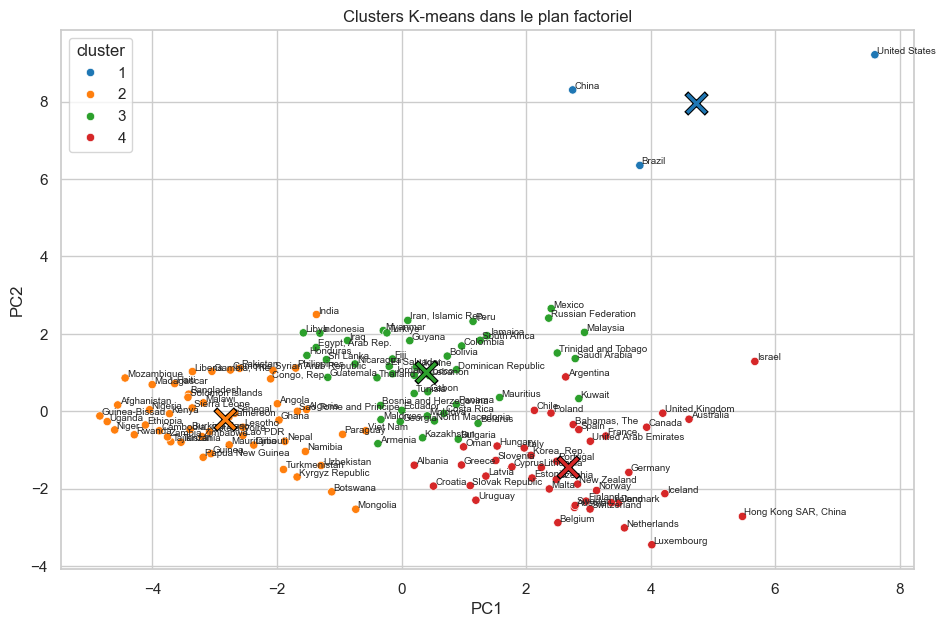

In [23]:
viz = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": df_clusters["cluster_kmeans"],
    "pays": df_clusters["pays"]
})

centroides = viz.groupby("cluster")[["PC1", "PC2"]].mean().reset_index()

plt.figure(figsize=(11, 7))
ax = sns.scatterplot(data=viz, x="PC1", y="PC2", hue="cluster", palette="tab10")
for _, row in viz.iterrows():
    ax.text(row["PC1"] + 0.03, row["PC2"] + 0.03, row["pays"], fontsize=7)



palette = sns.color_palette("tab10", n_colors=viz["cluster"].nunique())

for i, row in centroides.iterrows():
    # contour noir
    ax.scatter(
        row["PC1"],
        row["PC2"],
        s=220,
        marker="x",
        color="black",
        linewidths=4,
        zorder=5,
    )
    
    ax.scatter(
        row["PC1"],
        row["PC2"],
        s=180,
        marker="x",
        color=palette[i],
        linewidths=2.5,
        zorder=5,
    )

plt.title("Clusters K-means dans le plan factoriel")
plt.show()

## Comparaison CAH vs K-means

In [24]:
pd.crosstab(df_clusters['cluster_cah'], df_clusters['cluster_kmeans'])

cluster_kmeans,1,2,3,4
cluster_cah,,,,
1,0,47,3,0
2,3,0,0,0
3,0,2,41,5
4,0,2,2,37


La comparaison CAH / K-means permet de vérifier que la segmentation reste globalement cohérente d'une méthode à l'autre.

L'ARI calcule plus haut donne une mesure synthétique de cet accord, tandis que le tableau croise permet d'identifier les groupes les plus stables.

## 8. Profil moyen des 4 clusters

In [25]:
profile_vars = [
    'marche_volaille_tonnes',
    'pib_hab_ppp',
    'taux_dependance_import',
    'part_proteines_volaille_dans_viandes',
    'prix_moyen_import_volaille_usd_tonne',
    'proteines_animales_g_hab_jour',
    'sous_alimentation_pct',
    'cout_alimentation_saine_ppp_jour',
    'prevalence_inabordabilite_alimentation_saine_pct',
    'pct_population_urbaine',
    'croissance_population_urbaine_pct',
    'croissance_conso_volaille_pct',
    'croissance_import_volaille_pct',
    'score_stabilite_politique',
    'indice_gouvernance_moyen',
]
cluster_profile = df_clusters.groupby('cluster_kmeans')[profile_vars].mean().round(2)
cluster_profile

,marche_volaille_tonnes,pib_hab_ppp,taux_dependance_import,part_proteines_volaille_dans_viandes,prix_moyen_import_volaille_usd_tonne,proteines_animales_g_hab_jour,sous_alimentation_pct,cout_alimentation_saine_ppp_jour,prevalence_inabordabilite_alimentation_saine_pct,pct_population_urbaine,croissance_population_urbaine_pct,croissance_conso_volaille_pct,croissance_import_volaille_pct,score_stabilite_politique,indice_gouvernance_moyen
cluster_kmeans,,,,,,,,,,,,,,,
1,"15,160,076.110","29,876.400",0.010,0.410,"2,763.890",63.100,2.500,2.650,21.130,75.610,1.640,1.500,-0.380,61.940,60.320
2,"215,059.560","5,063.600",0.420,0.290,"1,663.420",20.250,16.860,3.230,59.830,43.100,3.480,3.660,13.760,55.740,43.380
3,"742,786.160","16,989.060",0.250,0.610,"1,628.830",39.760,6.410,3.230,29.860,64.160,1.710,2.400,1.300,58.300,49.370
4,"470,040.520","44,275.580",0.600,0.350,"2,916.630",66.690,2.750,2.780,12.940,77.780,0.980,0.490,4.390,78.490,74.740


### Caractérisation des clusters — 24 variables de l'ACP

Cette vue permet d'examiner les **24 variables retenues dans l'ACP** afin de documenter finement les différences entre clusters.

Les boxplots permettent de voir :
- la **médiane** de chaque cluster ;
- la **dispersion** des pays à l'intérieur du cluster ;
- la présence éventuelle de **valeurs extrêmes**.


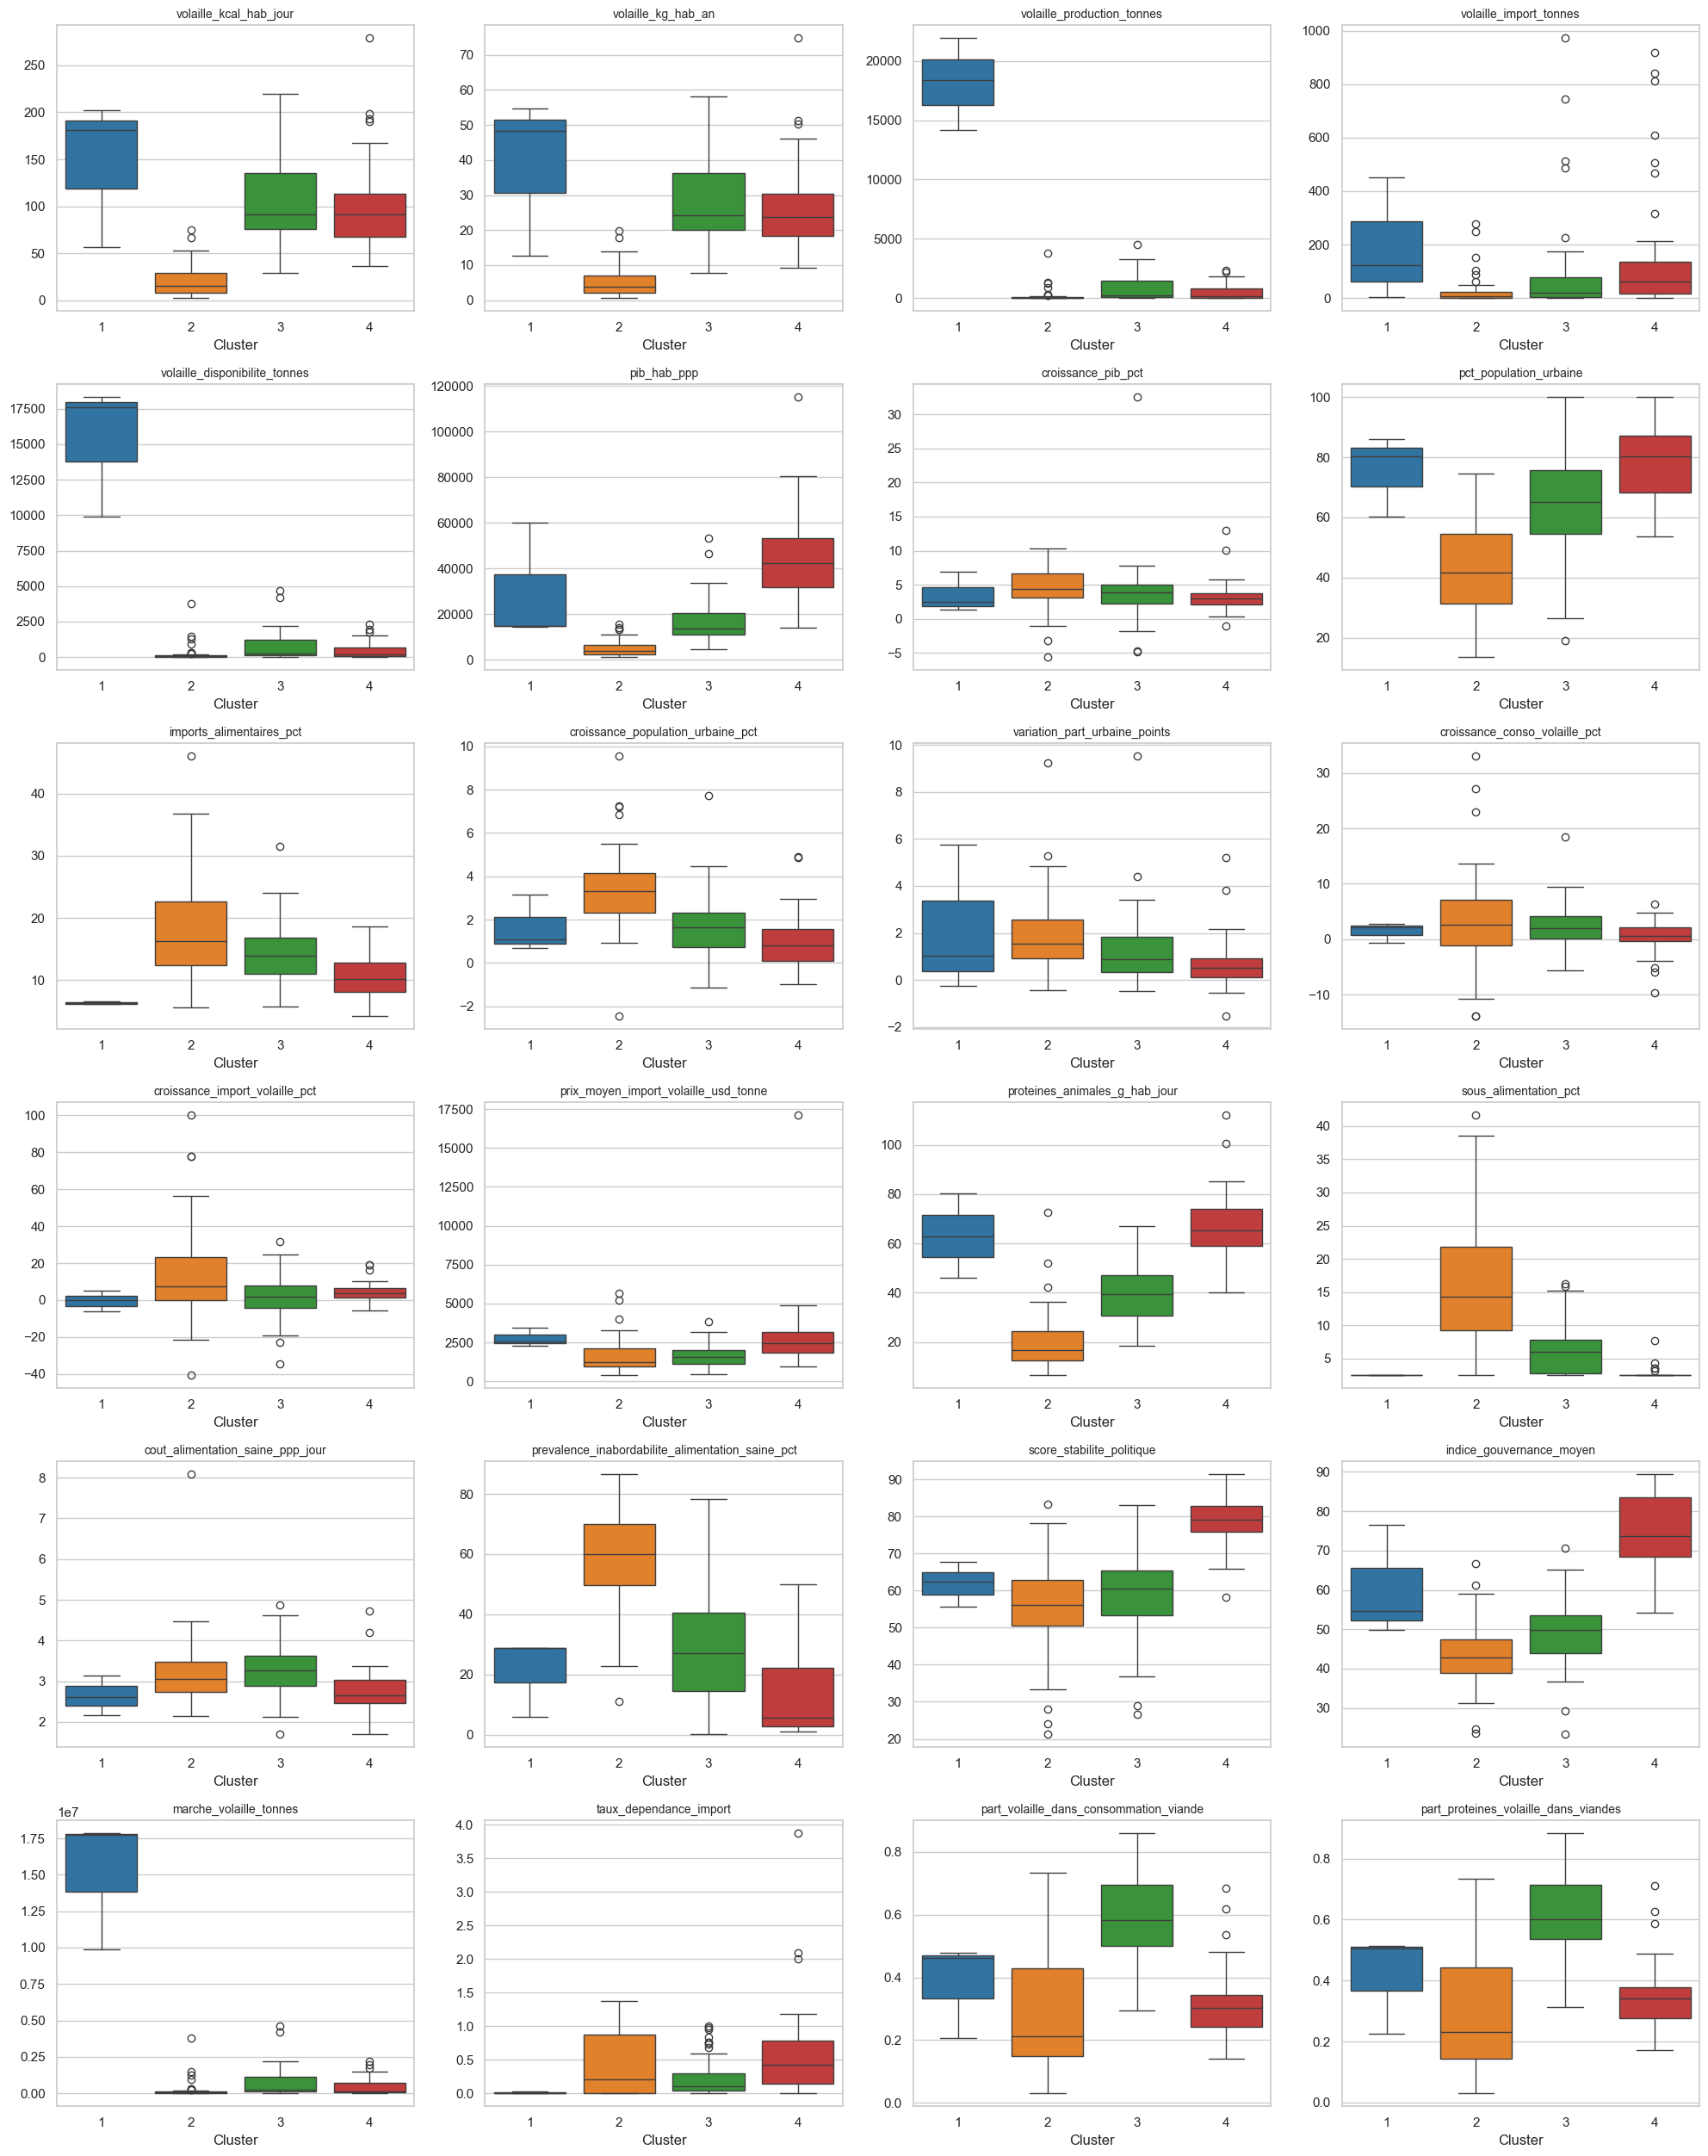

In [26]:
boxplot_vars_24 = MODELING_FEATURES.copy()

n_cols = 4
n_rows = int(np.ceil(len(boxplot_vars_24) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4.2 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, boxplot_vars_24):
    sns.boxplot(
    data=df_clusters,
    x='cluster_kmeans',
    y=col,
    hue='cluster_kmeans',
    ax=ax,
    palette='tab10',
    legend=False,
)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('Cluster')
    ax.set_ylabel('')

for ax in axes[len(boxplot_vars_24):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()
plt.close()

### Lecture métier des 4 clusters

Les 4 clusters peuvent être interprétés en **quatre grands profils de marché**:

- **Cluster 1 : Géants producteurs déjà installés**
  - marchés très volumineux ;
  - niveau de richesse correct à élevé ;
  - très faible dépendance aux importations ;
  - exemples typiques : **Etats-Unis**, **Chine**, **Brésil**.
  
  Ce profil regroupe de très grands marchés, mais souvent déjà largement couverts par une production locale importante. Ils sont stratégiques par leur taille, mais pas forcément les plus simples à pénétrer à court terme pour un exportateur.

- **Cluster 2 : Marchés émergents, fragiles mais dynamiques**
  - marchés plutôt petits à moyens ;
  - pouvoir d'achat plus limité ;
  - sous-alimentation et inabordabilité alimentaire plus élevées ;
  - croissance parfois forte de la consommation ou des importations de volaille ;
  - exemples typiques : **Philippines**, **Ghana**, **Sénégal**, **Liberia**, **Angola**.
  
  Ce profil correspond à des marchés en développement où le potentiel de croissance existe, mais avec un niveau de risque commercial plus élevé.

- **Cluster 3 : Marchés intermédiaires attractifs**
  - taille de marché intermédiaire à significative ;
  - niveau de richesse moyen à bon ;
  - dépendance aux importations modérée ;
  - bonne place de la volaille dans l'alimentation ;
  - exemples typiques : **Malaisie**, **Arabie saoudite**, **Kazakhstan**, **Turquie**, **Pérou**, **Costa Rica**.
  
  Ce profil regroupe des marchés plutôt équilibrés, avec un potentiel commercial intéressant et un profil souvent favorable au produit volaille.

- **Cluster 4 : Marchés riches, stables et importateurs**
  - marchés solvables et matures ;
  - stabilité politique et gouvernance élevées ;
  - urbanisation forte ;
  - dépendance aux importations souvent marquée ;
  - exemples typiques : **Émirats arabes unis**, **Danemark**, **Royaume-Uni**, **Pays-Bas**, **France**, **Allemagne**, **Suisse**.
  
  Ce profil correspond à des marchés plus sécurisants commercialement, souvent moins dynamiques que les marchés émergents, mais plus lisibles et plus confortables pour une stratégie d'exportation.

En synthèse, l'analyse fait ressortir :
- un profil de **très gros marchés déjà largement autonomes** ;
- un profil de **marchés émergents plus risqués mais dynamiques** ;
- un profil de **marchés intermédiaires bien équilibrés** ;
- un profil de **marchés riches, stables et importateurs**.


### Analyse des variables — quels clusters prioriser ?

Les boxplots permettent de dépasser la simple lecture des moyennes. Ils montrent quelles variables distinguent réellement les groupes, et aident à hiérarchiser les clusters d'un point de vue commercial.

Dans **l'exécution actuelle du notebook**, la lecture croisée des variables met en évidence quatre logiques :

- **Cluster 4** : c'est le groupe le plus prioritaire pour une stratégie d'export premium. Il combine en moyenne la meilleure solvabilité, la meilleure stabilité politique et la plus forte dépendance aux importations.
- **Cluster 3** : c'est le deuxième groupe le plus intéressant. Il présente un bon compromis entre potentiel commercial, spécialisation volaille et risque plus modéré que les marchés émergents.
- **Cluster 1** : il regroupe surtout des géants producteurs. Leur taille de marché est très forte, mais leur faible dépendance aux importations les rend moins prioritaires à court terme pour un exportateur.
- **Cluster 2** : il rassemble des marchés plus fragiles, plus dynamiques, mais aussi plus risqués. Ils peuvent constituer des opportunités secondaires, plutôt qu'une cible prioritaire immédiate.

En synthèse, les boxplots aident à justifier la hiérarchie suivante :
**cluster 4 en priorité**, **cluster 3 en second niveau**, puis **clusters 1 et 2** comme groupes plus secondaires ou plus spécifiques.

In [27]:
priority_vars = [
    'marche_volaille_tonnes',
    'pib_hab_ppp',
    'taux_dependance_import',
    'croissance_conso_volaille_pct',
    'part_volaille_dans_consommation_viande',
    'score_stabilite_politique',
    'indice_gouvernance_moyen',
]

cluster_priority_view = df_clusters.groupby('cluster_kmeans')[priority_vars].mean().round(2)
cluster_priority_view

,marche_volaille_tonnes,pib_hab_ppp,taux_dependance_import,croissance_conso_volaille_pct,part_volaille_dans_consommation_viande,score_stabilite_politique,indice_gouvernance_moyen
cluster_kmeans,,,,,,,
1,"15,160,076.110","29,876.400",0.010,1.500,0.380,61.940,60.320
2,"215,059.560","5,063.600",0.420,3.660,0.280,55.740,43.380
3,"742,786.160","16,989.060",0.250,2.400,0.590,58.300,49.370
4,"470,040.520","44,275.580",0.600,0.490,0.320,78.490,74.740


## 9. Recommandations pays - cibles commerciales

In [28]:
work = df_clusters.copy()

# Sous-scores interpretable metier
work['score_demande_actuelle'] = (
    work['marche_volaille_tonnes'].rank(pct=True) * 0.30
    + work['pib_hab_ppp'].rank(pct=True) * 0.15
    + work['taux_dependance_import'].rank(pct=True) * 0.15
    + work['pct_population_urbaine'].rank(pct=True) * 0.10
    + work['part_proteines_volaille_dans_viandes'].rank(pct=True) * 0.10
    + work['imports_alimentaires_pct'].fillna(work['imports_alimentaires_pct'].median()).rank(pct=True) * 0.10
    + (1 - work['prevalence_inabordabilite_alimentation_saine_pct'].fillna(work['prevalence_inabordabilite_alimentation_saine_pct'].median()).rank(pct=True)) * 0.10
)

work['score_dynamique'] = (
    work['croissance_population_urbaine_pct'].rank(pct=True) * 0.35
    + work['variation_part_urbaine_points'].rank(pct=True) * 0.20
    + work['croissance_conso_volaille_pct'].rank(pct=True) * 0.25
    + work['croissance_import_volaille_pct'].fillna(work['croissance_import_volaille_pct'].median()).rank(pct=True) * 0.20
)

work['score_environnement_commercial'] = (
    work['score_stabilite_politique'].rank(pct=True) * 0.25
    + work['indice_gouvernance_moyen'].rank(pct=True) * 0.20
    + (1 - work['sous_alimentation_pct'].fillna(work['sous_alimentation_pct'].median()).rank(pct=True)) * 0.15
    + (1 - work['cout_alimentation_saine_ppp_jour'].fillna(work['cout_alimentation_saine_ppp_jour'].median()).rank(pct=True)) * 0.15
    + (1 - work['prix_moyen_import_volaille_usd_tonne'].fillna(work['prix_moyen_import_volaille_usd_tonne'].median()).rank(pct=True)) * 0.15
    + work['proteines_animales_g_hab_jour'].rank(pct=True) * 0.10
)

work['score_cible'] = (
    work['score_demande_actuelle'] * 0.45
    + work['score_dynamique'] * 0.25
    + work['score_environnement_commercial'] * 0.30
)

shortlist_cols = [
    'pays',
    'cluster_kmeans',
    'score_cible',
    'score_demande_actuelle',
    'score_dynamique',
    'score_environnement_commercial',
    'marche_volaille_tonnes',
    'croissance_conso_volaille_pct',
    'taux_dependance_import',
    'part_proteines_volaille_dans_viandes',
    'prix_moyen_import_volaille_usd_tonne',
    'prevalence_inabordabilite_alimentation_saine_pct',
    'score_stabilite_politique',
    'indice_gouvernance_moyen',
]

work.sort_values('score_cible', ascending=False)[shortlist_cols].head(20)

,pays,cluster_kmeans,score_cible,score_demande_actuelle,score_dynamique,score_environnement_commercial,marche_volaille_tonnes,croissance_conso_volaille_pct,taux_dependance_import,part_proteines_volaille_dans_viandes,prix_moyen_import_volaille_usd_tonne,prevalence_inabordabilite_alimentation_saine_pct,score_stabilite_politique,indice_gouvernance_moyen
134,United Arab Emirates,4,0.721,0.745,0.687,0.714,"247,551.359",2.213,0.947,0.627,"1,734.024",3.700,78.181,72.383
31,Denmark,4,0.690,0.711,0.460,0.851,"145,392.796",2.997,0.911,0.302,"1,736.155",0.900,81.522,86.784
135,United Kingdom,4,0.669,0.757,0.426,0.739,"2,194,029.160",2.845,0.352,0.434,"2,847.924",3.700,73.422,81.133
94,Netherlands,4,0.669,0.768,0.324,0.807,"270,503.164",-9.568,2.097,0.259,"2,143.503",1.900,79.253,85.877
41,France,4,0.654,0.723,0.473,0.700,"1,708,417.051",1.738,0.289,0.314,"2,816.050",2.300,69.823,75.286
78,Luxembourg,4,0.637,0.565,0.585,0.789,"11,211.117",-1.510,1.091,0.245,"4,903.604",3.000,87.614,87.346
81,Malaysia,3,0.636,0.684,0.645,0.558,"1,690,905.955",1.654,0.040,0.785,"2,144.163",4.400,65.692,61.465
45,Germany,4,0.632,0.720,0.340,0.745,"1,484,519.756",-0.056,0.541,0.256,"2,507.837",2.800,77.890,83.717
123,Switzerland,4,0.632,0.595,0.513,0.787,"133,792.627",-0.484,0.388,0.269,"4,482.154",1.900,85.780,89.352
69,Kuwait,3,0.630,0.733,0.425,0.647,"187,963.695",-3.975,0.730,0.679,"2,150.032",NaN,65.926,53.487


## 9 bis. Éclairage bio sur les marchés les plus solvables

Sans modifier l'ACP ni le clustering, on peut ajouter ici un **éclairage complémentaire** sur le bio pour les marchés finaux les plus solvables.

Important : ces indicateurs décrivent le **marché bio global** du pays (ventes retail bio, importations bio, part de surface agricole bio) et **non une demande spécifique de poulet bio**.

Ils servent donc à **nuancer la lecture finale** : parmi les pays déjà attractifs commercialement, quels sont ceux qui semblent aussi évoluer dans un environnement bio plus mature ?

In [29]:
# Données bio FiBL : contexte de marché bio global, sans impact sur le modèle ACP
bio_retail = pd.read_excel(ROOT / 'data' / 'bio' / 'export-statistics8-8-2026.xlsx', header=9)
bio_trade = pd.read_excel(ROOT / 'data' / 'bio' / 'import-export.xlsx', header=9)

bio_retail = bio_retail.rename(columns={
    'Unnamed: 3': 'surface_bio_ha',
    'Unnamed: 4': 'part_surface_bio_pct',
    'Unnamed: 5': 'producteurs_bio',
    'Unnamed: 6': 'ventes_bio_millions_eur',
})

bio_trade = bio_trade.rename(columns={
    'Unnamed: 3': 'exportations_bio_millions_eur',
    'Unnamed: 4': 'importations_bio_millions_eur',
    'Unnamed: 5': 'ventes_bio_millions_eur_trade',
})

bio_retail = bio_retail.loc[bio_retail['Year'] == 2017, ['Country', 'part_surface_bio_pct', 'ventes_bio_millions_eur']].copy()
bio_trade = bio_trade.loc[bio_trade['Year'] == 2017, ['Country', 'importations_bio_millions_eur']].copy()

# Quelques harmonisations de noms pour rejoindre proprement nos pays finaux
bio_name_map = {
    'United States': 'United States of America',
    'Turkiye': 'Turkey',
}

#premium_final = work.sort_values('score_cible', ascending=False).loc[
#    lambda d: d['pib_hab_ppp'] >= 40000,
#    ['pays', 'cluster_kmeans','score_cible', 'pib_hab_ppp', 'score_stabilite_politique']
#].head(20).copy()

premium_final = work.sort_values('score_cible', ascending=False)[
    ['pays', 'cluster_kmeans', 'score_cible', 'pib_hab_ppp', 'score_stabilite_politique']
].head(20).copy()

premium_final['Country'] = premium_final['pays'].replace(bio_name_map)
premium_final['Country']

premium_bio = (
    premium_final
    .merge(bio_retail, on='Country', how='left')
    .merge(bio_trade, on='Country', how='left')
    .drop(columns='Country')
    .rename(columns={
        'ventes_bio_millions_eur': 'ventes_bio_millions_eur',
        'importations_bio_millions_eur': 'importations_bio_millions_eur',
        'part_surface_bio_pct': 'part_surface_bio_pct',
    })
)

premium_bio.sort_values('score_cible', ascending=False)[[
    'pays',
    'cluster_kmeans',
    'score_cible',
    'pib_hab_ppp',
    'score_stabilite_politique',
    'ventes_bio_millions_eur',
    'importations_bio_millions_eur',
    'part_surface_bio_pct',
]].round(2)

,pays,cluster_kmeans,score_cible,pib_hab_ppp,score_stabilite_politique,ventes_bio_millions_eur,importations_bio_millions_eur,part_surface_bio_pct
0,United Arab Emirates,4,0.720,"70,281.890",78.180,NaN,NaN,1.100
1,Denmark,4,0.690,"55,271.600",81.520,"1,600.670",518.610,8.600
2,United Kingdom,4,0.670,"46,113.020",73.420,"2,433.750",NaN,2.850
3,Netherlands,4,0.670,"56,037.570",79.250,"1,103.500",NaN,3.140
4,France,4,0.650,"44,469.150",69.820,"7,921.000","1,640.000",5.990
5,Luxembourg,4,0.640,"114,985.840",87.610,122.000,NaN,4.150
6,Malaysia,3,0.640,"26,415.600",65.690,NaN,NaN,0.010
7,Germany,4,0.630,"54,110.250",77.890,"10,340.000",NaN,8.210
8,Switzerland,4,0.630,"68,193.510",85.780,"2,435.000",NaN,14.480
9,Kuwait,3,0.630,"46,565.550",65.930,NaN,NaN,0.010


In [30]:
print("=== RÉPARTITION DES PAYS PAR CLUSTER ===")

def get_cluster_name(count_country):
    if count_country==3:
        return "- Géants producteurs déjà installés"
    elif count_country==51 :
        return "- Marchés émergents, fragiles mais dynamiques"
    elif count_country==46  :
        return "- Marchés intermédiaires attractifs"
    elif count_country==42  :
        return "- Marchés riches, stables et importateurs"
    else:
        return "- modification des clusters k-means ... "

for cluster_id in sorted(df_clusters['cluster_kmeans'].unique()):
    pays_cluster = df_clusters.loc[df_clusters['cluster_kmeans'] == cluster_id, 'pays'].tolist()
    print(f"\nCluster {cluster_id} {get_cluster_name(len(pays_cluster))} ({len(pays_cluster)} pays) :")
    for p in sorted(pays_cluster):
        print(f"  - {p}")


=== RÉPARTITION DES PAYS PAR CLUSTER ===

Cluster 1 - Géants producteurs déjà installés (3 pays) :
  - Brazil
  - China
  - United States

Cluster 2 - Marchés émergents, fragiles mais dynamiques (51 pays) :
  - Afghanistan
  - Algeria
  - Angola
  - Bangladesh
  - Botswana
  - Burkina Faso
  - Cambodia
  - Cameroon
  - Comoros
  - Congo, Rep.
  - Cote d'Ivoire
  - Djibouti
  - Ethiopia
  - Gambia, The
  - Ghana
  - Guinea
  - Guinea-Bissau
  - Haiti
  - India
  - Kenya
  - Kyrgyz Republic
  - Lao PDR
  - Lesotho
  - Liberia
  - Madagascar
  - Malawi
  - Mauritania
  - Mongolia
  - Mozambique
  - Namibia
  - Nepal
  - Niger
  - Nigeria
  - Pakistan
  - Papua New Guinea
  - Paraguay
  - Philippines
  - Rwanda
  - Sao Tome and Principe
  - Senegal
  - Sierra Leone
  - Solomon Islands
  - Syrian Arab Republic
  - Tajikistan
  - Tanzania
  - Turkmenistan
  - Uganda
  - Uzbekistan
  - Viet Nam
  - Zambia
  - Zimbabwe

Cluster 3 - Marchés intermédiaires attractifs (46 pays) :
  - Armenia
  - 

## 10. Export enrichi

In [31]:
output_path = ROOT / 'outputs' / 'dataset_p11_clusters.csv'
work.to_csv(output_path, index=False, encoding='utf-8-sig')
output_path

WindowsPath('D:/openclassroom/P11/outputs/dataset_p11_clusters.csv')

## Pourquoi utiliser les scores ACP pour le clustering ?

Les variables de départ sont nombreuses et parfois corrélées entre elles.
Passer par les scores ACP permet de :
- réduire la dimension du problème ;
- limiter l'effet de redondance entre variables proches ;
- faire travailler le clustering sur une représentation plus stable des pays.


## Explication vulgarisée des techniques utilisées

- **ACP** : on résume beaucoup de variables en quelques grands axes de lecture.
- **CAH** : on regroupe progressivement les pays les plus proches dans l'espace statistique.
- **K-means** : on stabilise ensuite un découpage final en quelques groupes.
- **Silhouette** : on mesure si les groupes sont bien sépares les uns des autres.

L'ensemble permet de passer d'un grand nombre d'indicateurs commerciaux à une segmentation de pays plus lisible pour la décision.
